In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

[*********************100%***********************]  1 of 1 completed


In [3]:
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

In [4]:
S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años

num_simulations = 10000

In [6]:
Z = np.random.normal(0, 1, num_simulations)
St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

In [7]:
K = 680

In [8]:
call = np.maximum(St - K, 0)
put = np.maximum(K - St, 0)

In [11]:
call_value = np.exp(-r * T) * np.mean(call)
put_value = np.exp(-r * T) * np.mean(put)

# Parte 1

In [14]:
# Definimos los escenarios de sigma
sigmas = [0.01, 0.10, 0.20, 0.40]
resultados_call = {}
resultados_put = {}
escenarios_precios = {}

# Reutilizamos tus variables previas (asegúrate de haber corrido las celdas anteriores)
# S0, r, T, num_simulations, K ya deben estar definidos

for s in sigmas:
    # Generamos los mismos choques aleatorios para comparar peras con peras
    Z = np.random.normal(0, 1, num_simulations)
    
    # Calculamos St para este sigma específico
    St = S0 * np.exp((r - 0.5 * s**2) * T + s * np.sqrt(T) * Z)
    escenarios_precios[f'sigma {s}'] = St
    
    # Calculamos valores de opciones
    call_payoffs = np.maximum(St - K, 0)
    put_payoffs = np.maximum(K - St, 0)
    
    resultados_call[f'sigma {s}'] = np.exp(-r * T) * np.mean(call_payoffs)
    resultados_put[f'sigma {s}'] = np.exp(-r * T) * np.mean(put_payoffs)

# Mostrar tablas
print("Valor de la Call por Escenario:")
print(pd.Series(resultados_call))
print("\nValor de la Put por Escenario:")
print(pd.Series(resultados_put))

Valor de la Call por Escenario:
sigma 0.01    12.995726
sigma 0.1     21.699171
sigma 0.2     34.938468
sigma 0.4     63.903621
dtype: float64

Valor de la Put por Escenario:
sigma 0.01     0.000000
sigma 0.1      8.246408
sigma 0.2     22.354880
sigma 0.4     49.386734
dtype: float64


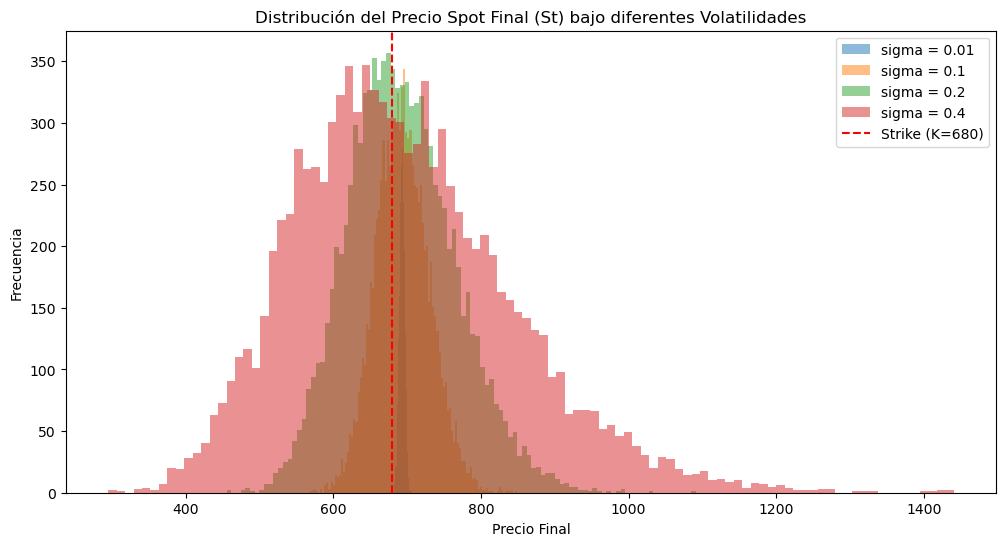

In [15]:
plt.figure(figsize=(12, 6))

for s in sigmas:
    plt.hist(escenarios_precios[f'sigma {s}'], bins=100, alpha=0.5, label=f'sigma = {s}')

plt.axvline(K, color='red', linestyle='--', label=f'Strike (K={K})')
plt.title('Distribución del Precio Spot Final (St) bajo diferentes Volatilidades')
plt.xlabel('Precio Final')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

## Preguntas

¿Qué sucede con la dispersión de las trayectorias?

Pues a mayor volatiliad se puede ver la incertidumbre es mucho mayor y la dispersion es mucho mayor

¿Cómo cambia la distribución de precios?

Pues con volatilidad baja parece un pico y con forme aumenta pordemos ver como se empieza a hacer campana y amplia, hasta el sesgo cambia

¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?

Siempre aumento


# Parte 2

In [16]:
# Definimos los escenarios de Tiempo (en días)
tiempos_dias = [30, 100, 365]
tiempos_anios = [t / 365 for t in tiempos_dias]

resultados_call_t = {}
resultados_put_t = {}
escenarios_precios_t = {}

# Fijamos sigma (puedes usar el sigma original de tu celda In [3])
sigma_fija = sigma 

for i, T_escenario in enumerate(tiempos_anios):
    nombre = f'{tiempos_dias[i]} dias'
    Z = np.random.normal(0, 1, num_simulations)
    
    # Simulación con el T variable
    St = S0 * np.exp((r - 0.5 * sigma_fija**2) * T_escenario + sigma_fija * np.sqrt(T_escenario) * Z)
    escenarios_precios_t[nombre] = St
    
    # Valoración
    call_v = np.exp(-r * T_escenario) * np.mean(np.maximum(St - K, 0))
    put_v = np.exp(-r * T_escenario) * np.mean(np.maximum(K - St, 0))
    
    resultados_call_t[nombre] = call_v
    resultados_put_t[nombre] = put_v

# Tablas de resultados
print("Valor Call por T:")
print(pd.Series(resultados_call_t))
print("\nValor Put por T:")
print(pd.Series(resultados_put_t))

Valor Call por T:
30 dias     15.140680
100 dias    32.600903
365 dias    75.761507
dtype: float64

Valor Put por T:
30 dias     12.586774
100 dias    18.762753
365 dias    25.572086
dtype: float64


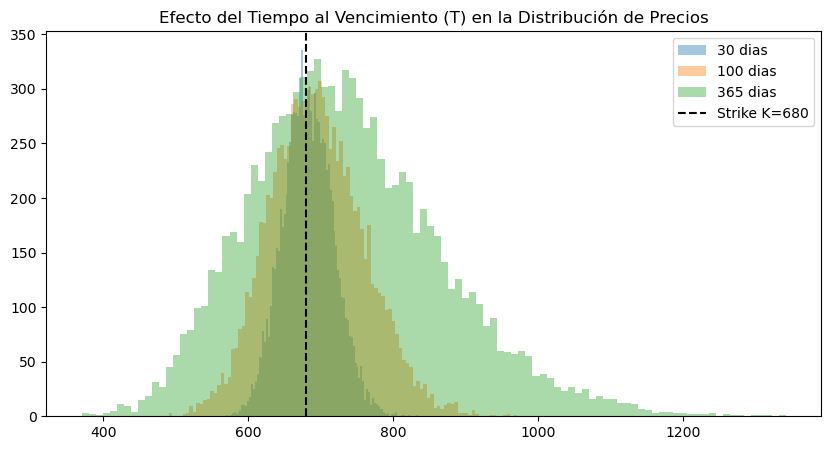

In [17]:
plt.figure(figsize=(10, 5))
for nombre, precios in escenarios_precios_t.items():
    plt.hist(precios, bins=100, alpha=0.4, label=nombre)

plt.axvline(K, color='black', linestyle='--', label=f'Strike K={K}')
plt.title('Efecto del Tiempo al Vencimiento (T) en la Distribución de Precios')
plt.legend()
plt.show()

## Preguntas

¿Cómo cambia la distribución final del precio al aumentar T?

De igual manera, a mayor tiempo mayor dispersión, y se mueven hacia la derecha

¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?

De la misma manera, siempre aumenta, ya que hay más probabilidad de ganancia basicamente

# Parte 3

In [18]:
# Definimos los factores de K respecto a S0
factores_K = [0.70, 0.90, 1.00, 1.10, 1.30]
escenarios_K = [S0 * f for f in factores_K]
nombres_K = ["70%", "90%", "S0 (At the money)", "110%", "130%"]

resultados_call_k = {}
resultados_put_k = {}

# Usamos los parámetros base de tu código anterior (sigma original y T original)
# Asegúrate de que St ya esté calculado para un escenario base
for i, K_escenario in enumerate(escenarios_K):
    # Valoración
    call_v = np.exp(-r * T) * np.mean(np.maximum(St - K_escenario, 0))
    put_v = np.exp(-r * T) * np.mean(np.maximum(K_escenario - St, 0))
    
    resultados_call_k[nombres_K[i]] = call_v
    resultados_put_k[nombres_K[i]] = put_v

# Mostrar resultados
print("Valor de la Call por Strike (K):")
print(pd.Series(resultados_call_k))
print("\nValor de la Put por Strike (K):")
print(pd.Series(resultados_put_k))

Valor de la Call por Strike (K):
70%                  254.224660
90%                  130.502314
S0 (At the money)     81.372610
110%                  45.971039
130%                  11.262289
dtype: float64

Valor de la Put por Strike (K):
70%                    0.271663
90%                    9.262428
S0 (At the money)     26.489281
110%                  57.444265
130%                 155.448628
dtype: float64


## Preguntas

¿Aumenta o disminuye el valor de la opción conforme aumenta K?

Si es un call, el valor disminuyenos conforme K aumenta y si es un put ocurre lo contrario

¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?

Cuando es muy alto, el call tiene un valor altosimo y el put es casi 0, cuando es muy bajo ocurre lo contrario

# Parte 4

In [19]:
# Escenarios de tasa libre de riesgo
tasas_r = [0.01, 0.05, 0.10]
nombres_r = ["r = 1%", "r = 5%", "r = 10%"]

resultados_call_r = {}
resultados_put_r = {}
escenarios_precios_r = {}

# Usamos sigma y T originales
for i, r_escenario in enumerate(tasas_r):
    Z = np.random.normal(0, 1, num_simulations)
    
    # El r_escenario afecta el crecimiento del precio
    St = S0 * np.exp((r_escenario - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    escenarios_precios_r[nombres_r[i]] = St
    
    # Valoración (el r_escenario también afecta el factor de descuento e^-rT)
    call_v = np.exp(-r_escenario * T) * np.mean(np.maximum(St - K, 0))
    put_v = np.exp(-r_escenario * T) * np.mean(np.maximum(K - St, 0))
    
    resultados_call_r[nombres_r[i]] = call_v
    resultados_put_r[nombres_r[i]] = put_v

# Mostrar resultados
print("Valor Call por Tasa r:")
print(pd.Series(resultados_call_r))
print("\nValor Put por Tasa r:")
print(pd.Series(resultados_put_r))

Valor Call por Tasa r:
r = 1%     25.231565
r = 5%     28.606126
r = 10%    34.494679
dtype: float64

Valor Put por Tasa r:
r = 1%     24.961397
r = 5%     21.622556
r = 10%    17.205819
dtype: float64


## Preguntas

¿Cómo cambia el crecimiento esperado del precio del activo?

El crecimiento aumenta proporcionalmente a la tasa 

¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?



¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?